# Practical 2: Gradients and material recovery

**Learning objective.** Trace a force-to-loss gradient by hand and with PyTorch, check a material-law derivative, then differentiate an elastic-bar solve and recover its modulus.

**Predict first.** For a stretched, damaged bar, how will a little more extension or a little more damage change its force?

<div class="badge-row">
<a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/classroom/02_gradients_and_recovery.ipynb"><img src="../_static/colab-badge.svg" alt="Open in Colab"/></a>
<a class="badge-link" href="../../notebooks/study/classroom/02_gradients_and_recovery.ipynb">Download Practice Notebook</a>
<a class="badge-link" href="../../notebooks/solutions/classroom/02_gradients_and_recovery.ipynb">Download with Worked Solutions</a>
<a class="badge-link" href="../../SETUP.md">Environment Setup</a>
</div>

Work through the cells in order. Expand setup and figure details when you want to inspect the complete implementation.


In [1]:
#@title Set up the course environment { display-mode: "form" }
# Environment setup is measured separately from the classroom computation.
from pathlib import Path
import importlib.metadata
import json
import os
import subprocess
import sys
import time

setup_started = time.perf_counter()
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not (3, 10) <= sys.version_info[:2] < (3, 13):
    raise RuntimeError("This PhAST snapshot supports Python 3.10–3.12. Select a compatible runtime; see Environment Setup.")

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        for candidate in (base, base / "autumn-school", base / "teaching/ukacm_autumn_school_2026"):
            if (candidate / "notebooks/day2_helpers").is_dir() and (candidate / "vendor/PhAST/src").is_dir():
                return candidate.resolve()
    return None

COURSE_ROOT = locate_course_root()
if COURSE_ROOT is None and IN_COLAB:
    COURSE_ROOT = Path.cwd() / "autumn-school"
    if COURSE_ROOT.exists():
        raise RuntimeError("An incomplete autumn-school folder exists. Start a fresh runtime or select the complete course folder.")
    # A release tag or full commit can be supplied for a fixed course edition.
    course_ref = os.environ.get("PHAST_COURSE_REF", "main")
    subprocess.run(["git", "init", str(COURSE_ROOT)], check=True, capture_output=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "remote", "add", "origin", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "fetch", "--depth", "1", "origin", course_ref], check=True, timeout=180)
    subprocess.run(["git", "-C", str(COURSE_ROOT), "checkout", "--detach", "FETCH_HEAD"], check=True, capture_output=True)
if COURSE_ROOT is None:
    raise FileNotFoundError("Open the notebook from the complete course folder, including notebooks/, configs/ and vendor/. See Environment Setup.")

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", str(COURSE_ROOT / "vendor/PhAST"), "nbformat", "nbclient", "nbconvert"], check=True, timeout=600)

for package_dir in (COURSE_ROOT / "vendor/PhAST/src", COURSE_ROOT / "notebooks"):
    if str(package_dir) not in sys.path:
        sys.path.insert(0, str(package_dir))

revision = subprocess.run(["git", "-C", str(COURSE_ROOT), "rev-parse", "HEAD"], text=True, capture_output=True)
package_versions = {}
for package in ("torch", "numpy", "scipy", "matplotlib", "nbformat"):
    try:
        package_versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        package_versions[package] = "install using Environment Setup"
import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display
from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)
plt.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "legend.fontsize": 10,
    "figure.titlesize": 13, "figure.dpi": 150, "axes.grid": True,
    "grid.alpha": 0.3, "grid.linestyle": "--", "lines.linewidth": 1.8,
})

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Retain figures for reading in the book and in a fresh notebook session."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

# Include dependency imports and plotting configuration in the setup duration.
setup_receipt = {
    "environment": "Google Colab" if IN_COLAB else "local",
    "python": sys.version.split()[0],
    "course_revision": revision.stdout.strip() if revision.returncode == 0 else "downloaded archive",
    "versions": package_versions,
    "setup_seconds": round(time.perf_counter() - setup_started, 3),
}
print(setup_receipt)

session_started = time.perf_counter()
torch.set_num_threads(1)

{'environment': 'local', 'python': '3.10.18', 'course_revision': '48ae30794de3da1f4242bfbefff124dfd0d9a594', 'versions': {'torch': '2.8.0', 'numpy': '2.2.6', 'scipy': '1.14.1', 'matplotlib': '3.10.8', 'nbformat': '5.10.4'}, 'setup_seconds': 1.108}


## Physical motivation and equations

A derivative quantifies how a chosen output changes when one input changes. We begin with a local damaged bar whose extension and damage are prescribed. Then we connect that chain rule to a public material law and an equilibrium solve.

### Begin with a damaged bar

For a bar with Young's modulus $E$, cross-sectional area $A$, reference length $L_b$, extension $u$ and uniform damage $d$, the axial force is

$$g(d)=(1-d)^2,\qquad F(u,d)=\frac{EA}{L_b}\,g(d)\,u.$$

All quantities use dimensionless teaching scales. This local constitutive example takes $E=2$, $A=L_b=1$, zero residual stiffness ($\kappa=0$), and $0<d<1$. The two inputs are collected in $\mathbf q=(u,d)=(0.1,0.5)$. Increasing $u$ stretches the bar further; increasing $d$ reduces its stiffness. Hold the other input fixed when reasoning about each change.

Suppose the target force is $F^\star=0.04$. Define the residual $r=F-F^\star$ and the scalar squared-mismatch loss $\mathcal L=\tfrac12r^2$. Damage is a prescribed input in this first calculation. The later equilibrium example introduces a solved displacement field.

### Compute the forward values

`requires_grad=True` asks PyTorch to record how subsequent tensor operations depend on $\mathbf q$. Unpacking its entries preserves that connection. Follow the values from inputs to degradation, force, residual and loss.

In [2]:
q = torch.tensor([.1, .5], dtype=torch.float64, requires_grad=True)
u, damage = q.unbind()
E, A, L_b, target_force = 2., 1., 1., .04
degradation = (1. - damage) ** 2
force = (E * A / L_b) * degradation * u
residual = force - target_force
primer_loss = .5 * residual ** 2
print({"degradation": float(degradation.detach()), "force": float(force.detach()),
       "residual": float(residual.detach()), "loss": float(primer_loss.detach())})

{'degradation': 0.25, 'force': 0.05, 'residual': 0.010000000000000002, 'loss': 5.000000000000002e-05}


The forward values are $g=0.25$, $F=0.05$, $r=0.01$ and $\mathcal L=5\times10^{-5}$. The force is slightly above its target.

### Work backwards with the chain rule

Start with the loss sensitivity to force, $\partial\mathcal L/\partial F=r=0.01$. The two local force sensitivities are

$$\frac{\partial F}{\partial u}=\frac{EA}{L_b}(1-d)^2=0.5,
\qquad
\frac{\partial F}{\partial d}=-2\frac{EA}{L_b}(1-d)u=-0.2.$$

Multiply each by the same loss seed:

$$\frac{\partial\mathcal L}{\partial u}=0.01(0.5)=0.005,
\qquad
\frac{\partial\mathcal L}{\partial d}=0.01(-0.2)=-0.002.$$

These signs describe this evaluation point: a small increase in extension raises the loss; a small increase in damage lowers it. They follow from both the material response and the current force mismatch.

### Ask PyTorch for the same derivatives

`primer_loss.backward()` applies that chain rule to the recorded operations. `q.grad` contains $\nabla_{\mathbf q}\mathcal L$ in the order `[u, damage]`. Re-run the forward cell before repeating this backward cell to create a fresh graph. An optimisation step would subsequently choose how to change the inputs using this gradient.

In [3]:
primer_loss.backward()
print("[d(loss)/du, d(loss)/dd] =", q.grad.tolist())
manual_gradient = residual.detach() * torch.stack([
    (E * A / L_b) * (1 - damage.detach()) ** 2,
    -2 * (E * A / L_b) * (1 - damage.detach()) * u.detach()])
torch.testing.assert_close(q.grad, manual_gradient)

[d(loss)/du, d(loss)/dd] = [0.005000000000000001, -0.0020000000000000005]


### Check the gradient and inspect its meaning

The check below independently evaluates central differences, $[\mathcal L(\mathbf q+h\mathbf e_i)-\mathcal L(\mathbf q-h\mathbf e_i)]/(2h)$, with $h=10^{-6}$. Here $\mathbf e_i$ changes only input $i$. The helper records the analytic, autograd and finite-difference results in a CSV and a JSON file. The two force curves vary one input at a time around the same evaluation point.

In [4]:
from day2_helpers.autodiff_primer import verify_primer
from day2_helpers.autodiff_primer import force_sensitivities, forward_reverse_graph
practical_dir = assets_dir() / "classroom" / "02"
primer_check = verify_primer(q, q.grad, practical_dir)
for method in ("autograd", "analytic", "central_fd"):
    print(method, primer_check["loss_gradient_" + method])

autograd [0.005000000000000001, -0.0020000000000000005]
analytic [0.005000000000000001, -0.0020000000000000005]
central_fd [0.005000000000007576, -0.00199999999996034]


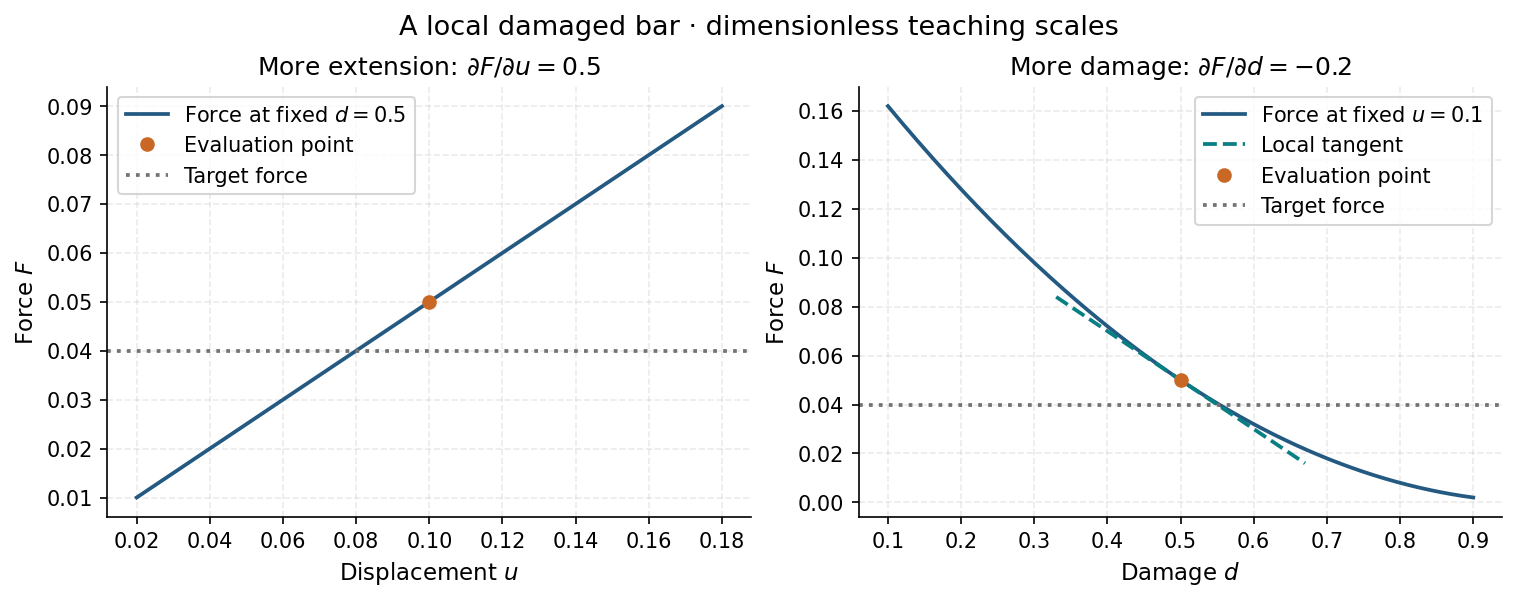

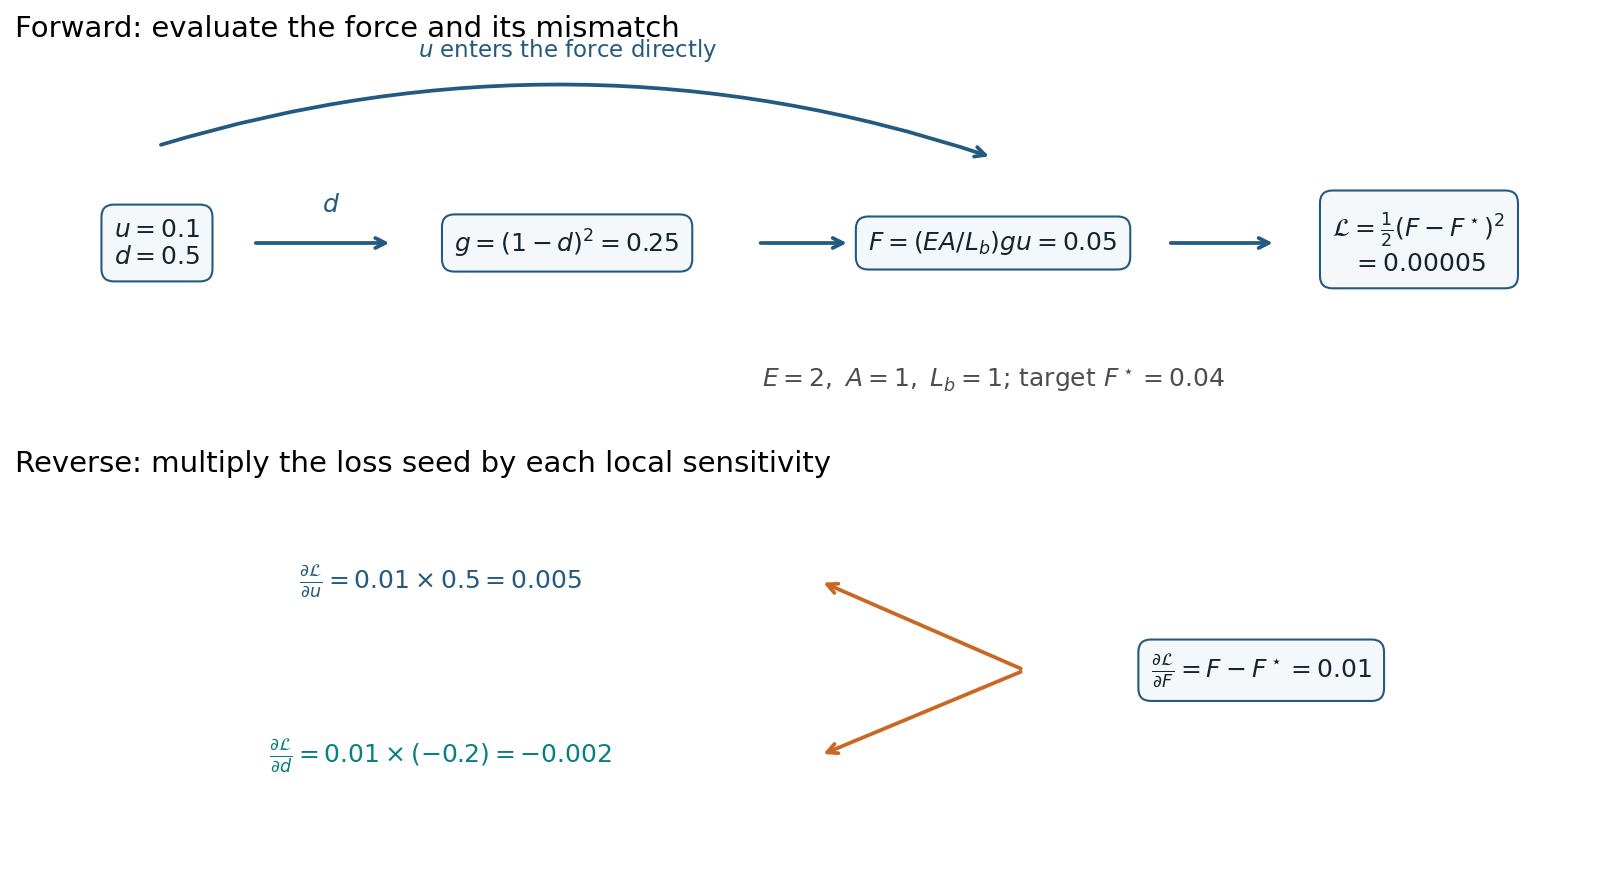

In [5]:
fig = force_sensitivities(primer_check, practical_dir)
display_figure(fig, alt="Force increases with extension and decreases with prescribed damage; the evaluation point, target force and local damage tangent are marked.")
plt.close(fig)
fig = forward_reverse_graph(primer_check, practical_dir)
display_figure(fig, alt="Forward values from prescribed displacement and damage to force and loss, then the loss seed multiplied by each local force derivative.")
plt.close(fig)

### Predict and check: move each input separately

Keeping the target force fixed, predict what happens to the force and loss when (a) $u$ changes from $0.1$ to $0.101$, and (b) $d$ changes from $0.5$ to $0.501$. Change only one input at a time. Use $\Delta\mathcal L\approx(\partial\mathcal L/\partial q_i)\Delta q_i$ for your first estimate, then check the exact values below.

<details><summary>Hint</summary>

At the starting point, $\Delta\mathcal L\approx0.005\Delta u-0.002\Delta d$. Compare the new force with $F^\star=0.04$.

</details>

In [6]:
with torch.no_grad():
    for label, delta in (("More extension", [.001, 0.]), ("More damage", [0., .001])):
        changed = q.detach() + torch.tensor(delta, dtype=q.dtype)
        trial_force = (E * A / L_b) * (1 - changed[1]) ** 2 * changed[0]
        trial_loss = .5 * (trial_force - target_force) ** 2
        print(label, {"force": float(trial_force), "loss": float(trial_loss),
                      "loss_change": float(trial_loss - primer_loss.detach())})

More extension {'force': 0.0505, 'loss': 5.5125000000000025e-05, 'loss_change': 5.125000000000003e-06}
More damage {'force': 0.0498002, 'loss': 4.802196002000002e-05, 'loss_change': -1.9780399800000035e-06}


<details><summary>Worked Solution</summary>

With $u=0.101$ and $d=0.5$, the force rises to $0.0505$ and the loss rises to $0.000055125$: $\Delta\mathcal L=0.000005125$, close to the first-order estimate $0.000005$.

With $u=0.1$ and $d=0.501$, the force falls to $0.0498002$ and the loss falls to about $0.00004802196$: $\Delta\mathcal L\approx-0.00000197804$, close to $-0.000002$. The gradient is a local linear approximation; finite changes also contain higher-order terms.

</details>

### Connect local derivatives to equilibrium

The damaged-bar calculation makes a scalar forward and backward pass explicit. We now inspect PhAST's degradation law, then differentiate a small mechanics graph in which a material parameter changes a solved response:

$$E\ \longrightarrow\ K(E)\ \longrightarrow\ \mathbf u\ \longrightarrow\ \mathcal L\ \longrightarrow\ \frac{\partial\mathcal L}{\partial E}.$$

Here $K(E)$ is the assembled stiffness matrix, $\mathbf u$ contains nodal displacements, and $\mathcal L$ measures displacement mismatch. The recovery example is a **one-dimensional linear-elastic bar** with a fixed left end, length $L=1$, area $A=1$ and tip force $F$. It uses 40 finite elements and dimensionless teaching scales. Its response is $u_{\mathrm{tip}}=FL/(EA)$. Under a fixed positive force, predict how increasing $E$ changes the tip displacement. Fracture evolution introduces additional coupled and history-dependent operations.

## Step-by-step calculation

### A local derivative: stiffness degradation

The normalised law $g(d)=(1-\eta)(1-d)^2+\eta$ reduces stiffness with damage $d$, retaining residual stiffness $\eta=10^{-7}$. Its slope is $g'(d)=-2(1-\eta)(1-d)$. Compare the public implementation, calculus and central differences.

In [7]:
from day2_helpers import import_public_phast
phast_info = import_public_phast()
from phast.physics.material import Material
eta = 1.e-7
material = Material(E=1., nu=.3, Gc=1., l0=.1, rho=1., eta_residual=eta)
def g_analytic(d):
    return (1.0 - eta) * (1.0 - d) ** 2 + eta
def gp_analytic(d):
    return -2.0 * (1.0 - eta) * (1.0 - d)

`requires_grad=True` marks the chosen input. `torch.autograd.grad` differentiates the scalar output along the recorded tensor operations. Detaching the input lets us evaluate an independent finite-difference comparison.

In [8]:
d = torch.tensor(.25, requires_grad=True)
g_phast = material.degradation(d)
(g_ad,) = torch.autograd.grad(g_phast, d)
h = 1.e-6
g_fd = (g_analytic(d.detach() + h) - g_analytic(d.detach() - h)) / (2 * h)
expected = gp_analytic(d.detach())
print({"autograd": float(g_ad), "finite_difference": float(g_fd),
       "analytic": float(expected)})

{'autograd': -1.49999985, 'finite_difference': -1.4999998499964917, 'analytic': -1.49999985}


The endpoint checks confirm the meaning of intact and fully damaged material. The derivative checks compare this scalar material operation in float64.

In [9]:
endpoints = material.degradation(torch.tensor([0.0, 1.0], dtype=torch.float64))
ad_error = abs(float(g_ad - expected))
fd_error = abs(float(g_fd - expected))
assert abs(float(endpoints[0]) - 1.0) < 1.0e-12
assert abs(float(endpoints[1]) - eta) < 1.0e-12
assert ad_error < 1.0e-12
assert fd_error < 1.0e-8
print({"g(0)": float(endpoints[0]), "g(1)": float(endpoints[1]), "AD_error": ad_error, "FD_error": fd_error})

{'g(0)': 1.0, 'g(1)': 1e-07, 'AD_error': 0.0, 'FD_error': 3.5083047578154947e-12}


The degradation curve connects the numerical derivative to its physical meaning: the stiffness contribution decreases as damage grows.

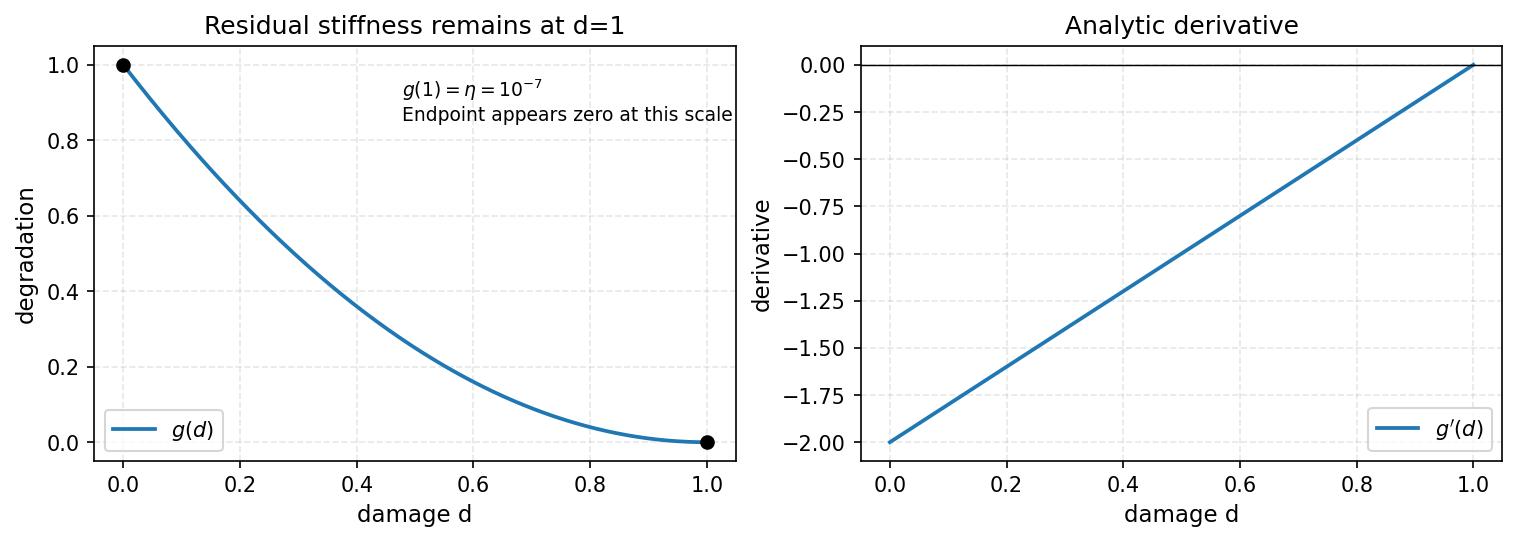

In [10]:
practical_dir = assets_dir() / "classroom" / "02"
practical_dir.mkdir(parents=True, exist_ok=True)
d_plot = torch.linspace(0.0, 1.0, 400, dtype=torch.float64)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].plot(d_plot, material.degradation(d_plot), label=r"$g(d)$")
axes[0].scatter([0, 1], endpoints, color="black", zorder=3)
axes[0].set(xlabel="damage d", ylabel="degradation", title="Residual stiffness remains at d=1")
axes[0].text(.48, .82, r"$g(1)=\eta=10^{-7}$" + "\nEndpoint appears zero at this scale", transform=axes[0].transAxes, fontsize=9)
axes[0].legend()
axes[1].plot(d_plot, gp_analytic(d_plot), label=r"$g'(d)$")
axes[1].axhline(0, color="black", lw=0.7)
axes[1].set(xlabel="damage d", ylabel="derivative", title="Analytic derivative")
axes[1].legend()
fig.savefig(practical_dir / "degradation_autograd.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Standard degradation function and its analytic derivative over damage from zero to one.")
plt.close(fig)

### Assemble a one-dimensional bar

Each element has stiffness $(EA/h)\begin{bmatrix}1&-1\\-1&1\end{bmatrix}$, where $h=L/40$. Assemble `K0` with unit modulus, so the differentiable scalar $E$ multiplies the complete matrix. Node zero is the fixed left end.

In [11]:
torch.manual_seed(20260909)
n_elements, length, area = 40, 1.0, 1.0
h = length / n_elements
K0 = torch.zeros((n_elements + 1, n_elements + 1))
local = torch.tensor([[1., -1.], [-1., 1.]]) * area / h
for e in range(n_elements):
    K0[e:e+2, e:e+2] += local
print({"stiffness_shape": tuple(K0.shape), "free_displacements": n_elements})

{'stiffness_shape': (41, 41), 'free_displacements': 40}


Remove the fixed degree of freedom, apply the tip force at the final node, then solve equilibrium. The returned tip displacement remains connected to `E` through `torch.linalg.solve`.

In [12]:
def tip_displacement(E, load):
    K_free = (E * K0)[1:, 1:]
    force = torch.zeros(n_elements)
    force[-1] = load
    return torch.linalg.solve(K_free, force)[-1]

Locate the fixed node, free nodes and applied force before differentiating equilibrium. The diagram uses the same 40-element topology as the assembled matrix.

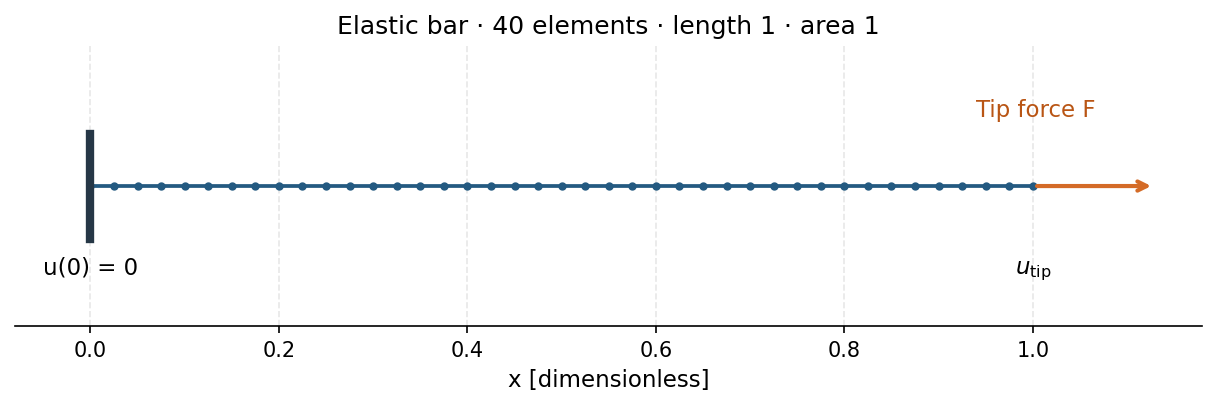

In [13]:
from day2_helpers.classroom_visuals import bar_setup, bar_sensitivity, bar_initial_observations
fig = bar_setup(n_elements, length, area, practical_dir)
display_figure(fig, alt="One-dimensional 40-element bar, fixed left end and tip force at the right.")
plt.close(fig)

### Differentiate through equilibrium

For the uniform bar, $\partial u_{\mathrm{tip}}/\partial E=-u_{\mathrm{tip}}/E$. Check the sign and magnitude against the finite-element graph and a central difference.

In [14]:
E_probe = torch.tensor(1.8, dtype=torch.float64, requires_grad=True)
u_probe = tip_displacement(E_probe, 1.1)
(du_dE_ad,) = torch.autograd.grad(u_probe, E_probe)
h_fd = 1.0e-6
du_dE_fd = (tip_displacement(E_probe.detach() + h_fd, 1.1) - tip_displacement(E_probe.detach() - h_fd, 1.1)) / (2*h_fd)
du_dE_exact = -u_probe.detach() / E_probe.detach()
print({"u_tip": float(u_probe.detach()), "AD": float(du_dE_ad), "FD": float(du_dE_fd), "analytic": float(du_dE_exact)})
assert abs(float(du_dE_ad - du_dE_exact)) < 1.0e-12
assert abs(float(du_dE_fd - du_dE_exact)) < 1.0e-8

{'u_tip': 0.6111111111111187, 'AD': -0.33950617283949214, 'FD': -0.3395061727862192, 'analytic': -0.3395061728395104}


All three sensitivity estimates are negative: a larger modulus reduces the extension under a fixed force. The step-size sweep shows how finite-difference agreement depends on the perturbation, using the same equilibrium function. The CSV retains every diagnostic value.

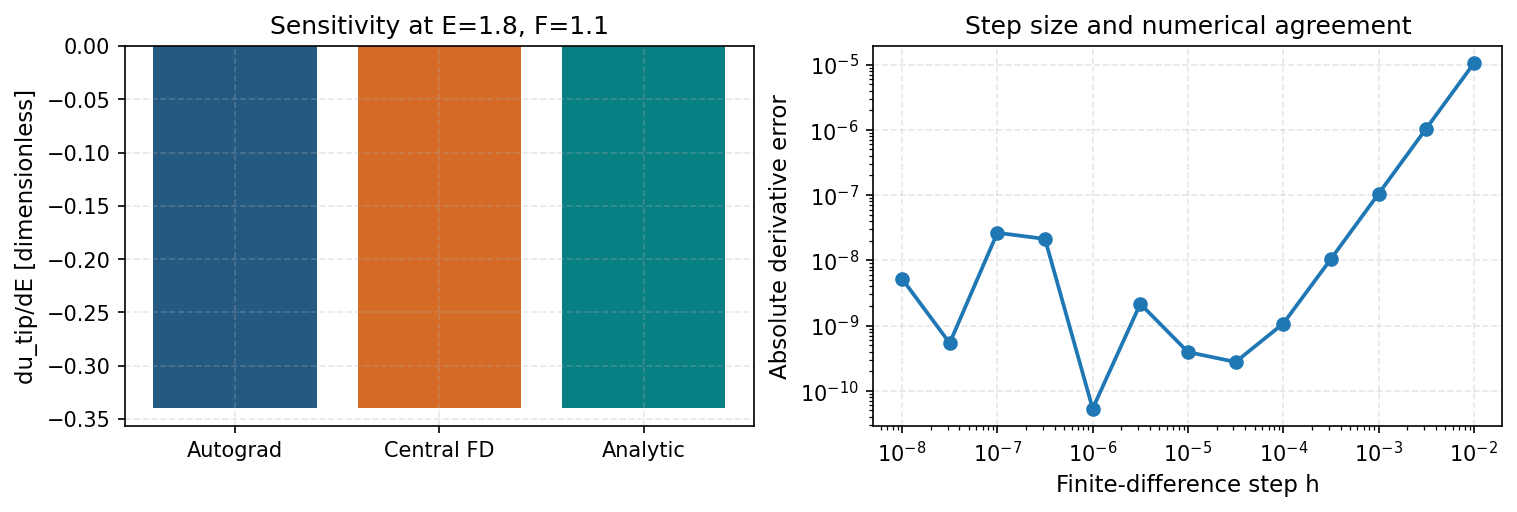

In [15]:
fig = bar_sensitivity(tip_displacement, E_probe, 1.1, du_dE_ad, du_dE_fd, du_dE_exact, practical_dir)
display_figure(fig, alt="Negative bar sensitivity from autograd, finite differences and calculus, with finite-difference error versus step size.")
plt.close(fig)

### Create synthetic observations

The known modulus generates displacement observations at separate training, validation and held-out loads. Detaching observations treats them as fixed measurements during recovery.

In [16]:
# Whole load cases are kept separate: train, validation, and held-out.
E_true = torch.tensor(2.4, dtype=torch.float64)
train_loads = torch.tensor([0.35, 0.75, 1.15, 1.55], dtype=torch.float64)
validation_load = torch.tensor(0.95, dtype=torch.float64)
heldout_load = torch.tensor(1.35, dtype=torch.float64)
observed_train = torch.stack([tip_displacement(E_true, load) for load in train_loads]).detach()
observed_validation = tip_displacement(E_true, validation_load).detach()
observed_heldout = tip_displacement(E_true, heldout_load).detach()

Plot the observations before fitting. The starting modulus 0.9 gives a steeper displacement–load response than the target modulus 2.4. Training, validation and held-out loads are marked separately.

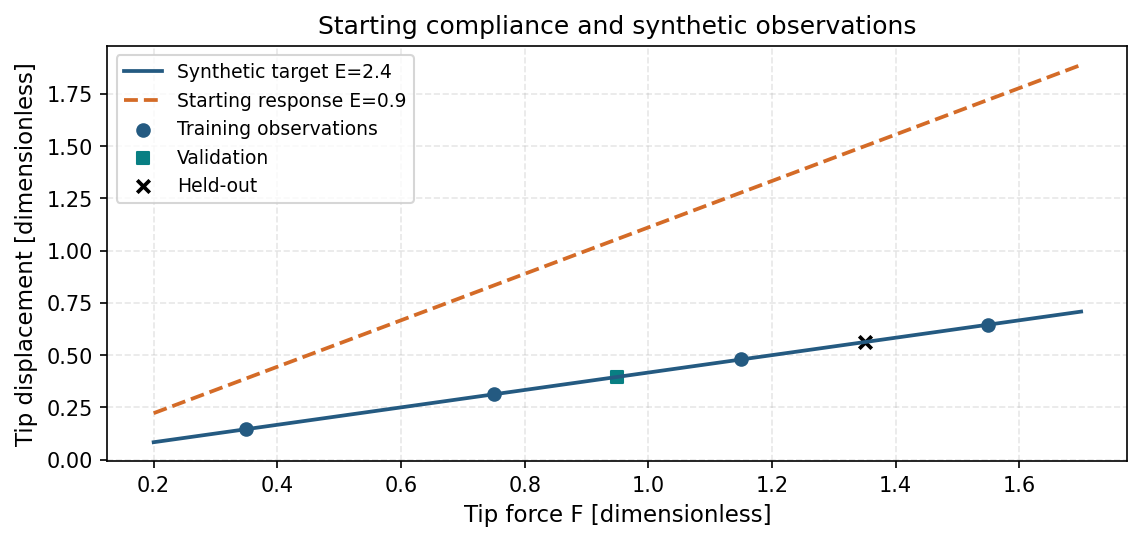

In [17]:
fig = bar_initial_observations(tip_displacement, .9, E_true, train_loads, observed_train,
                               validation_load, observed_validation, heldout_load, observed_heldout, practical_dir)
display_figure(fig, alt="Starting and target elastic-bar responses with distinct training, validation and held-out observation loads.")
plt.close(fig)

### Recover a positive modulus

Represent stiffness as $E=\exp(z)$, with the trainable scalar `log_E` storing $z$. This gives positive stiffness. Minimise the mean squared displacement mismatch $\mathcal L=M^{-1}\sum_{i=1}^M(u_i(E)-u_i^{\mathrm{obs}})^2$, where $M=4$ training loads.

In [18]:
log_E = torch.nn.Parameter(torch.log(torch.tensor(.9)))
optimiser = torch.optim.Adam([log_E], lr=.08)
history = []

Each iteration clears the previous gradients, evaluates the four equilibrium responses, differentiates the scalar loss and updates the log modulus. Validation observes an additional load without contributing to the training gradient.

In [19]:
for iteration in range(180):
    optimiser.zero_grad(set_to_none=True)
    E_trial = torch.exp(log_E)
    predicted = torch.stack([tip_displacement(E_trial, load) for load in train_loads])
    loss = torch.mean((predicted - observed_train) ** 2)
    loss.backward()
    optimiser.step()
    if iteration % 10 == 0 or iteration == 179:
        with torch.no_grad():
            val_error = abs(tip_displacement(torch.exp(log_E), validation_load) - observed_validation)
            fitted = float(torch.exp(log_E))
        history.append((iteration + 1, fitted, float(loss.detach()), float(val_error)))

## Interpret the recovered response

Compare the recovered modulus and the held-out tip displacement, then inspect both the load-response curve and optimisation history. All observations here come from the same linear-elastic bar model.

In [20]:
E_fit = torch.exp(log_E).detach()
heldout_prediction = tip_displacement(E_fit, heldout_load)
print({"E_true": float(E_true), "E_fit": float(E_fit), "heldout_observed": float(observed_heldout), "heldout_prediction": float(heldout_prediction)})
assert abs(float(E_fit - E_true)) < 2.0e-3

{'E_true': 2.4, 'E_fit': 2.400302387627723, 'heldout_observed': 0.562499999999992, 'heldout_prediction': 0.5624291368281488}


Agreement at an additional positive load checks the fitted compliance. Both history curves show root-mean-square displacement error at the same recorded, updated modulus. Training uses four loads; validation uses one load, for which RMSE equals absolute displacement error. New geometries, nonlinear material laws and noisy observations would require their own evaluations.

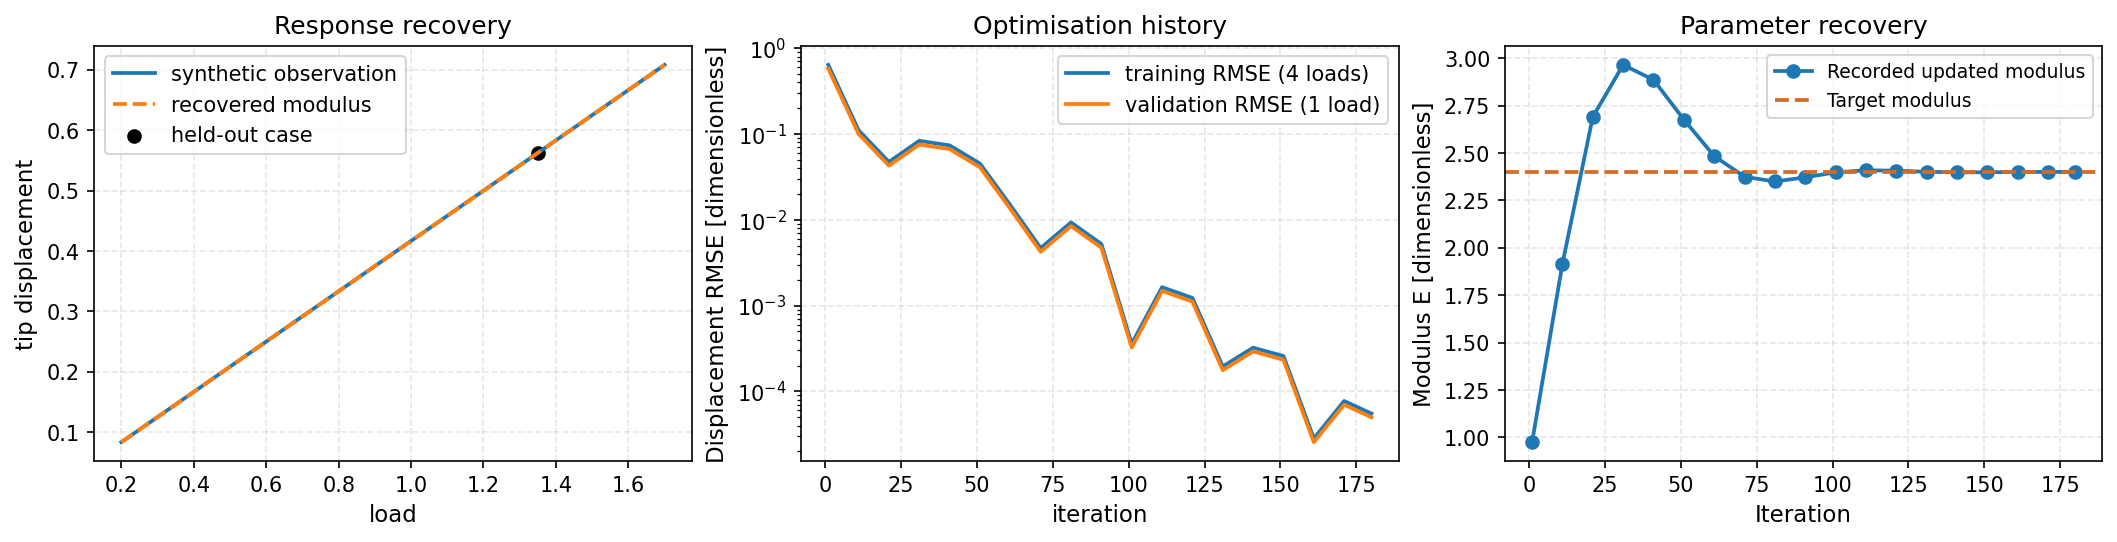

In [21]:
history_array = np.array(history)
training_rmse = []
with torch.no_grad():
    for fitted_modulus in history_array[:, 1]:
        responses = torch.stack([tip_displacement(torch.tensor(fitted_modulus), load) for load in train_loads])
        training_rmse.append(float((responses - observed_train).square().mean().sqrt()))
response_loads = torch.linspace(0.2, 1.7, 80, dtype=torch.float64)
true_response = np.array([float(tip_displacement(E_true, load)) for load in response_loads])
fit_response = np.array([float(tip_displacement(E_fit, load)) for load in response_loads])
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
axes[0].plot(response_loads, true_response, label="synthetic observation")
axes[0].plot(response_loads, fit_response, "--", label="recovered modulus")
axes[0].scatter([heldout_load], [observed_heldout], color="black", label="held-out case")
axes[0].set(xlabel="load", ylabel="tip displacement", title="Response recovery")
axes[0].legend()
axes[1].semilogy(history_array[:, 0], training_rmse, label="training RMSE (4 loads)")
axes[1].semilogy(history_array[:, 0], history_array[:, 3], label="validation RMSE (1 load)")
axes[1].set(xlabel="iteration", ylabel="Displacement RMSE [dimensionless]", title="Optimisation history")
axes[1].legend()
axes[2].plot(history_array[:, 0], history_array[:, 1], "o-", label="Recorded updated modulus")
axes[2].axhline(float(E_true), color="#d46b27", linestyle="--", label="Target modulus")
axes[2].set(xlabel="Iteration", ylabel="Modulus E [dimensionless]", title="Parameter recovery")
axes[2].legend(fontsize=9)
from day2_helpers.classroom_visuals import save_table
save_table([{"iteration": int(row[0]), "updated_modulus": float(row[1]),
             "pre_update_training_mse": float(row[2]), "training_rmse": rmse,
             "validation_rmse": float(row[3])} for row, rmse in zip(history_array, training_rmse)],
           practical_dir / "bar_recovery_history.csv")
np.savez_compressed(practical_dir / "bar_recovery_results.npz", loads=response_loads.numpy(),
                    target_response=true_response, recovered_response=fit_response,
                    recorded_history=history_array, matched_training_rmse=np.array(training_rmse),
                    E_true=float(E_true), E_fit=float(E_fit))
fig.savefig(practical_dir / "tiny_inverse_bar.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Elastic-bar response, matched training/validation displacement RMSE, and updated modulus across recovery.")
plt.close(fig)

### Example outline · P2-R01 · Fracture inverse recovery

**Learning question:** Which fracture parameters can be recovered from specified observations?

**Planned content.** Extend the parameter–observation–loss sequence to a small fracture problem, with recovery histories and held-out observations. The elastic bar above supplies the current executable exercise.

### Animation storyboard · P2-A01 · Forward values and backward sensitivities

**Planned content.** Follow $E$, the stiffness matrix, tip displacement and scalar mismatch forwards, then follow the derivative backwards. Show the optimisation update as a separate final step.

## Key takeaways

- A scalar loss supplies a reverse seed; the chain rule converts local force sensitivities into input gradients.
- The degradation slope describes how local stiffness changes with damage.
- Autograd differentiates the finite-element solve connecting the modulus to tip displacement.
- Positive modulus recovery and a held-out load check the fitted linear-bar compliance.

## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Derive two sensitivities

For $g(d)=(1-\eta)(1-d)^2+\eta$, derive its slope and explain its sign. For the fixed-left bar, derive $u_{\mathrm{tip}}$ and $\partial u_{\mathrm{tip}}/\partial E$. How do these two gradients enter different computational graphs?

::::{admonition} Hint 1
:class: dropdown course-hint

Differentiate the square in $g$. For the bar, use axial force balance and $u_{\mathrm{tip}}=FL/(EA)$.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

The degradation slope is $g'(d)=-2(1-\eta)(1-d)$, which is negative for $d<1$ when $0\le\eta<1$: increased damage reduces stiffness. The bar has $u_{\mathrm{tip}}=FL/(EA)$ and $\partial u_{\mathrm{tip}}/\partial E=-FL/(AE^2)$: increased modulus reduces extension under a fixed load. The first derivative is local to a material law. The second passes through the assembled equilibrium solve. A coupled fracture sensitivity additionally includes the damage/history operations that connect the chosen parameter to the observable.
::::

### Exercise 2: Explore positive stiffness and additional observations

1. Let $z=\log E$. Derive $\partial u_{\mathrm{tip}}/\partial z$ from the chain rule. What values of stiffness can this parameterisation represent?
2. Use `tip_displacement` to compare the recovered and reference bar over several positive loads. Plot both responses and their difference.
3. Explain what an additional load observation tests in this linear bar model. What extra experiment would help if the material response were nonlinear?

::::{admonition} Hint 2
:class: dropdown course-hint

Use $\partial E/\partial z=E$ and the sensitivity from Exercise 1. The notebook supplies `E_fit`, `E_true` and the callable `tip_displacement`.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

The exponential maps each real $z$ to a positive stiffness. Applying the chain rule gives

$$
\frac{\partial u_{\mathrm{tip}}}{\partial z}
=-\frac{FL}{AE^2}E=-u_{\mathrm{tip}}.
$$

```python
loads = torch.linspace(0.2, 1.5, 12, dtype=torch.float64)
with torch.no_grad():
    reference = torch.stack([tip_displacement(E_true, force) for force in loads])
    recovered = torch.stack([tip_displacement(E_fit, force) for force in loads])
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), layout="constrained")
axes[0].plot(loads, reference, label="reference")
axes[0].plot(loads, recovered, "--", label="recovered")
axes[0].set(xlabel="tip load F", ylabel="tip displacement")
axes[0].legend()
axes[1].plot(loads, recovered - reference)
axes[1].set(xlabel="tip load F", ylabel="displacement difference")
display_figure(fig)
```

Both curves are straight lines in this uniform linear-elastic model. An additional load tests the recovered compliance on another observation, while repeated noisy measurements help quantify uncertainty. A nonlinear material would require observations spanning the relevant strain range; unloading measurements could also reveal irreversible response.
::::

## Continue studying

[Detailed notebook 02](https://github.com/CEMS-Lab/autumn-school/blob/main/notebooks/02_degradation_autograd.ipynb) · [Detailed notebook 03](https://github.com/CEMS-Lab/autumn-school/blob/main/notebooks/03_tiny_derivative_inverse_toy.ipynb)

The complete source, attribution and bundled licences remain in the [course repository](https://github.com/CEMS-Lab/autumn-school/blob/main/ATTRIBUTION.md).

### Session timing

Elapsed session time includes reading and pauses between cells. The course runner measures uninterrupted computation separately from installation.

In [22]:
session_seconds = time.perf_counter() - session_started
print({"setup_seconds": setup_receipt["setup_seconds"],
       "elapsed_session_seconds": round(session_seconds, 2),
       "environment": setup_receipt["environment"], "torch": torch.__version__})

{'setup_seconds': 1.108, 'elapsed_session_seconds': 3.34, 'environment': 'local', 'torch': '2.8.0'}
